In [39]:
import os
os.getcwd()

'/home/hp/Desktop/DL/DeepLearning/tf_env'

In [40]:
os.listdir()

['Basic.ipynb',
 'models',
 'pyvenv.cfg',
 'download.jpeg',
 'bin',
 '.ipynb_checkpoints',
 'lib',
 'lib64',
 'cifar-10-batches-py',
 'Image_detection.ipynb',
 'include']

In [41]:
CIFAR_DIR = 'cifar-10-batches-py/'

In [42]:
dirs = ['batches.meta','data_batch_1','data_batch_2','data_batch_3','data_batch_4','data_batch_5','test_batch']

In [43]:
all_data = [0,1,2,3,4,5,6]

In [44]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        cifar_dict = pickle.load(fo, encoding='bytes')
    return cifar_dict

In [45]:
for i,direc in zip(all_data,dirs):
    all_data[i] = unpickle(CIFAR_DIR+direc)

In [46]:
batch_meta = all_data[0]
data_batch1 = all_data[1]
data_batch2 = all_data[2]
data_batch3 = all_data[3]
data_batch4 = all_data[4]
data_batch5 = all_data[5]
test_batch = all_data[6]

In [47]:
data_batch1

{b'batch_label': b'training batch 1 of 5',
 b'labels': [6,
  9,
  9,
  4,
  1,
  1,
  2,
  7,
  8,
  3,
  4,
  7,
  7,
  2,
  9,
  9,
  9,
  3,
  2,
  6,
  4,
  3,
  6,
  6,
  2,
  6,
  3,
  5,
  4,
  0,
  0,
  9,
  1,
  3,
  4,
  0,
  3,
  7,
  3,
  3,
  5,
  2,
  2,
  7,
  1,
  1,
  1,
  2,
  2,
  0,
  9,
  5,
  7,
  9,
  2,
  2,
  5,
  2,
  4,
  3,
  1,
  1,
  8,
  2,
  1,
  1,
  4,
  9,
  7,
  8,
  5,
  9,
  6,
  7,
  3,
  1,
  9,
  0,
  3,
  1,
  3,
  5,
  4,
  5,
  7,
  7,
  4,
  7,
  9,
  4,
  2,
  3,
  8,
  0,
  1,
  6,
  1,
  1,
  4,
  1,
  8,
  3,
  9,
  6,
  6,
  1,
  8,
  5,
  2,
  9,
  9,
  8,
  1,
  7,
  7,
  0,
  0,
  6,
  9,
  1,
  2,
  2,
  9,
  2,
  6,
  6,
  1,
  9,
  5,
  0,
  4,
  7,
  6,
  7,
  1,
  8,
  1,
  1,
  2,
  8,
  1,
  3,
  3,
  6,
  2,
  4,
  9,
  9,
  5,
  4,
  3,
  6,
  7,
  4,
  6,
  8,
  5,
  5,
  4,
  3,
  1,
  8,
  4,
  7,
  6,
  0,
  9,
  5,
  1,
  3,
  8,
  2,
  7,
  5,
  3,
  4,
  1,
  5,
  7,
  0,
  4,
  7,
  5,
  5,
  1,
  0,
  9,
  6,
  9,
 

In [48]:
data_batch1.keys()

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])

In [49]:
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np

In [50]:
x = data_batch1[b"data"]

In [51]:
x = x.reshape(10000, 3, 32,32).transpose(0,2,3,1).astype('uint8')

In [52]:
x[0].max()

255

In [53]:
(x[0]/255).max()

1.0

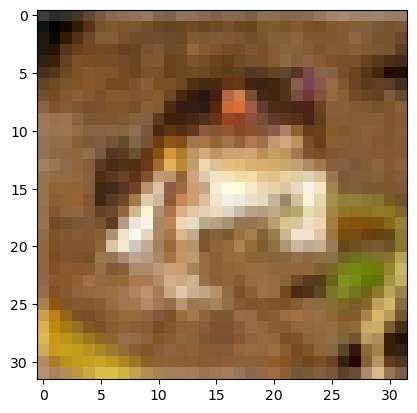

In [54]:
plt.imshow(x[0])
plt.show()

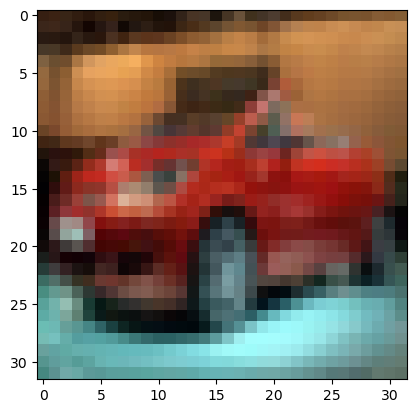

In [55]:
plt.imshow(x[45])
plt.show()

In [56]:
def one_hot_encode(vec, vals=10):
    n = len(vec)
    out = np.zeros((n, vals))
    out[range(n), vec] = 1
    return out

In [57]:
class ChiferHelper():
    
    def __init__(self):
        self.i = 0

        self.all_train_batch = [data_batch1,data_batch2,data_batch3,data_batch4,data_batch5]
        self.test_batch = [test_batch]

        self.traning_images = None
        self.traning_labes = None

        self.test_images = None
        self.test_labels = None

    def set_up_images(self):
        print("Set up training images and labels")

        self.training_images = np.vstack([d[b"data"] for d in  self.all_train_batch])
        train_len = len(self.training_images)

        self.training_images = self.training_images.reshape(train_len, 3, 32,32).transpose(0,2,3,1)/255
        self.training_labels = one_hot_encode(np.hstack([d[b"labels"] for d in self.all_train_batch]),10)


        print("Set up test images and labels")
        
        self.test_images = np.vstack([d[b"data"] for d in self.test_batch])
        test_len = len(self.test_images)

        self.test_images = self.test_images.reshape(test_len, 3, 32,32).transpose(0,2,3,1)/255
        self.test_labels = one_hot_encode(np.hstack([d[b"labels"] for d in self.test_batch]), 10)

    def next_batch(self, batch_size):
        x = self.training_images[self.i:self.i + batch_size].reshape(batch_size, 32, 32, 3)
        y = self.training_labels[self.i:self.i + batch_size]
        self.i = (self.i + batch_size) % len(self.training_images)
        return x, y

In [58]:
ch = ChiferHelper()
ch.set_up_images()

Set up training images and labels
Set up test images and labels


In [59]:
import tensorflow as tf
tf.compat.v1.disable_eager_execution()

In [60]:
x = tf.compat.v1.placeholder(tf.float32,shape=[None,32,32,3])
y_true = tf.compat.v1.placeholder(tf.float32,shape=[None,10])
hold_prob = tf.compat.v1.placeholder(tf.float32)

In [61]:
def init_weights(shape):
    init_random_dist = tf.compat.v1.truncated_normal(shape, stddev = 0.1)
    return tf.compat.v1.Variable(init_random_dist)

def init_bais(shape):
    init_bais_vals = tf.compat.v1.constant(0.1, shape=shape)
    return tf.compat.v1.Variable(init_bais_vals)

def conv2d(x,W):
    return tf.nn.conv2d(x, W, strides = [1,1,1,1], padding = 'SAME')

def max_pool_2by2(x):
    return tf.nn.max_pool(x, ksize = [1,2,2,1],strides = [1,2,2,1], padding = 'SAME')

def convolutional_layer(input_x, shape):
    W = init_weights(shape)
    b = init_bais([shape[3]])
    return tf.compat.v1.nn.relu(conv2d(input_x, W) +b)

def normal_full_layer(input_layer, size):
    input_size = int(input_layer.get_shape()[1])
    W = init_weights([input_size, size])
    b = init_bais([size])
    return tf.matmul(input_layer, W) +b

In [62]:
convo_1 = convolutional_layer(x, shape = [4,4,3,32])
convo_pooling_1 = max_pool_2by2(convo_1)

In [63]:
convo_2 = convolutional_layer(convo_pooling_1, shape = [4,4,32,64])
convo_pooling_2 = max_pool_2by2(convo_2)

In [64]:
8*8*64

4096

In [65]:
convo_2_flat = tf.reshape(convo_pooling_2, [-1, 8*8*64])

In [66]:
full_layer_one = tf.nn.relu(normal_full_layer(convo_2_flat,1024))

In [67]:
full_one_dropout = tf.compat.v1.nn.dropout(full_layer_one, keep_prob=hold_prob)

In [68]:
y_pred = normal_full_layer(full_one_dropout,10)

In [69]:
cross_entropy = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(labels = y_true, logits =y_pred))

In [70]:
optimizer = tf.compat.v1.train.AdamOptimizer(learning_rate = 0.001)
train = optimizer.minimize(cross_entropy)

In [71]:
init = tf.compat.v1.global_variables_initializer()

In [72]:
with tf.compat.v1.Session() as sess:
    sess.run(init)

    for i in range(500):
        batch = ch.next_batch(100)
        sess.run(train, feed_dict = {x: batch[0], y_true: batch[1], hold_prob:0.5})

        if i%100 ==0:
            print("Current on step {} ".format(i))
            print("Accuracy is: ")

            matches = tf.equal(tf.argmax(y_true, 1),tf.argmax(y_pred, 1))
            acc = tf.reduce_mean(tf.cast(matches, tf.float32))

            print(sess.run(acc,feed_dict = {x: ch.test_images, y_true :ch.test_labels, hold_prob:1.0}))
            print('\n')

Current on step 0 
Accuracy is: 
0.1005


Current on step 100 
Accuracy is: 
0.4202


Current on step 200 
Accuracy is: 
0.4641


Current on step 300 
Accuracy is: 
0.5051


Current on step 400 
Accuracy is: 
0.514


